# Модель для прогнозирования оттока клиентов для сервиса доставки кофе

# План работы

## Этап 1. Подготовка среды и библиотек
1. Установите и настройте библиотеки. Для воспроизводимости результатов зафиксируйте версии пакетов в файле `requirements.txt`.

2. Зафиксируйте `random_state`.

3. Загрузите данные из CSV-файла. Путь к файлу: `'/datasets/coffee_churn_dataset.csv'`. Используйте сепаратор `","`, а для чтения чисел с плавающей точкой — параметр `decimal="."`.

In [113]:
# Импорт библиотек
import numpy as np
import pandas as pd
import joblib

from sklearn.model_selection import cross_validate, StratifiedKFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, FunctionTransformer
from sklearn.metrics import average_precision_score, make_scorer, f1_score, precision_score, recall_score
from sklearn.dummy import DummyClassifier
from category_encoders import TargetEncoder

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# Фиксация random_state
RANDOM_STATE = 42

In [114]:
# Загрузка данных
# Указать ссылку к файлу
link = "/home/deck/Desktop/DATA SCIENCE/s12_happy_beans_coffee_project/datasets/coffee_churn_dataset.csv"
df = pd.read_csv(link, decimal=".")

In [115]:
# Проверка загрузки df
df.shape

(10450, 27)

## Этап 2. Первичный анализ данных

1. Опишите данные. Кратко сообщите, что известно о пользователях и их поведении.

2. Опишите целевую переменную. Обратите внимание на возможные особенности её распределения. Проверьте, наблюдается ли дисбаланс классов в целевой переменной.

3. Опишите признаки.

   - Определите, все ли из них важны.

   - Объясните, какие из них можно удалить (если такие есть). Аргументируйте своё решение.

4. Обработайте пропущенные значения.
   
   - Объясните, как они влияют на данные.

   - Выберите стратегию заполнения пропусков.

5. Проанализируйте категориальные признаки.

   - Выясните, есть ли в данных признаки, которые можно кодировать. Объясните, почему именно их нужно кодировать.

   - Проанализируйте признаки на предмет того, можно ли использовать некоторые из них для генерации новых  признаков. Укажите возможные стратегии.

   - Определите, есть ли в данных признаки, которые можно удалить.

6. Проанализируйте выбросы.

   - Определите, как они влияют на данные.

   - Выберите способ, которым их можно обработать.

7. Посчитайте корреляции между признаками. Постройте необходимые визуализации. Определите, есть ли признаки, которые можно убрать, на основании их корреляции с другими.

8. Напишите выводы по результатам исследовательского анализа данных.

In [116]:
# Знакомство с данными
df.head(10)

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,...,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
1,user_07234,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,...,1.0,4.392991,NaN,0.0,autumn,16.0,ios,0.0,geo_95,0
2,user_04816,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,...,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25,0
3,user_04419,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,...,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
4,user_09698,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,...,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19,1
5,user_01247,0.0,1.284824,0.418197,1092.164843,338.082043,471.825472,159.366225,0.350490,arabica,...,0.0,4.235214,4.835587,1.0,winter,17.0,android,0.0,geo_68,0
6,user_08887,5.0,6.124180,1.214905,428.486273,174.449445,1088.359993,254.120345,0.146130,robusta,...,NaN,4.406612,4.144391,0.0,spring,9.0,android,0.0,geo_3,0
7,user_01885,3.0,4.640247,1.029297,27.368788,9.812365,NaN,10.523663,0.173646,robusta,...,1.0,4.793547,4.321319,3.0,NaN,12.0,android,0.0,geo_3,1
8,user_03703,9.0,3.303446,NaN,1886.543949,964.629212,3312.557597,748.655191,0.676576,blend,...,1.0,4.405572,NaN,0.0,spring,5.0,android,0.0,geo_45,0
9,user_01536,0.0,0.310724,-0.094052,607.847810,NaN,151.508968,-41.895977,NaN,blend,...,1.0,4.362385,2.624536,2.0,autumn,14.0,ios,0.0,geo_2,0


In [117]:
# Описание назначения столбцов
column_descriptions = {
    "user_id": "идентификатор пользователя",
    "days_since_last_order": "количество дней, прошедших с последнего заказа",
    "order_frequency_month": "среднее число заказов в месяц",
    "order_frequency_week": "среднее число заказов в неделю",
    "avg_order_value": "средний чек, в рублях",
    "median_order_value": "медианный чек, в рублях",
    "total_spent_last_month": "сумма заказов за последний месяц",
    "total_spent_last_week": "сумма заказов за последнюю неделю",
    "discount_usage_rate": "доля заказов со скидкой за последний месяц",
    "last_coffee_type": "сорт кофе, купленный пользователем в последний раз на момент сбора данных",
    "preferred_roast": "предпочитаемый тип обжарки",
    "milk_preference": "предпочитаемый тип молока",
    "seasonal_menu_tried": "отметка о том, пробовал ли пользователь новейшее сезонное меню",
    "coffee_bean_origin": "страна происхождения зерна",
    "last_drink_size": "размер последнего заказа, совершённого на момент сбора данных",
    "subscription_status": "тип подписки пользователя",
    "app_opens_per_week": "сколько раз за неделю пользователь в среднем открывал приложение доставки кофе",
    "notifications_enabled": "включены ли у пользователя уведомления",
    "review_rating_last_10": "средняя оценка последних на момент сбора данных десяти заказов клиента",
    "review_rating_last_1": "оценка последнего на момент сбора данных заказа клиента",
    "app_crashes_last_month": "сколько раз приложение зависало за последний месяц",
    "seasons": "текущее время года",
    "days_since_last_promo": "сколько дней прошло с последнего использования акции или промокода",
    "phone_type": "тип устройства, с которого пользователь чаще всего совершал покупки",
    "coffee_preference_change": "менялись ли вкусовые предпочтения пользователя",
    "geo_location": "идентификатор региона пользователя",
    "churn": "перестал ли пользователь пользоваться сервисом"
}

In [118]:
# Собираем статистику по столбцам
def get_column_info(df):
    n_rows = len(df)
    df_info = []

    for col in df.columns:
        col_data = df[col]
        
        # Тип данных
        col_type = str(col_data.dtype)
        
        # Счет не пустых (не nan)
        count_non_null = col_data.notna().sum()
        
        # Счет nan
        count_nan = col_data.isna().sum()
        
        # Счет 0 или пусто
        if col_type != 'str' and  col_type != 'object':
            count_zero = (col_data == 0).sum()
            min = col_data.min()
            max = col_data.max()
            count_less_zero = (col_data < 0).sum()
        else:
            count_zero = (col_data == '').sum()
            min = np.nan
            max = np.nan
            count_less_zero = np.nan
            
        # Проценты
        isnan_percent = (count_nan / n_rows) * 100 if n_rows > 0 else 0
        iszero_percent = (count_zero / n_rows) * 100 if n_rows > 0 else 0
        less_zero_percent = (count_less_zero / n_rows) * 100 if n_rows > 0 else 0
        
        
        df_info.append({
            'column': col,
            'descr':column_descriptions[col],
            'count': count_non_null,
            'isnan': count_nan,
            'iszero': count_zero,
            'less_zero': count_less_zero,
            
            'isnan_%': isnan_percent,
            'iszero_%': iszero_percent,
            'less_zero_%': less_zero_percent,
            'min': min,
            'max': max,
            'col_type': col_type})
    
    return pd.DataFrame(df_info)
get_column_info(df)

,column,descr,count,isnan,iszero,less_zero,isnan_%,iszero_%,less_zero_%,min,max,col_type
0,user_id,идентификатор пользователя,10450,0,0,NaN,0.000000,0.000000,NaN,NaN,NaN,str
1,days_since_last_order,"количество дней, прошедших с последнего заказа",9505,945,1763,0.0,9.043062,16.870813,0.000000,0.000000,40.000000,float64
2,order_frequency_month,среднее число заказов в месяц,9850,600,0,0.0,5.741627,0.000000,0.000000,0.011046,27.389318,float64
3,order_frequency_week,среднее число заказов в неделю,10062,388,0,83.0,3.712919,0.000000,0.794258,-0.169131,6.302624,float64
4,avg_order_value,"средний чек, в рублях",9867,583,0,2.0,5.578947,0.000000,0.019139,-32.075932,5901.965278,float64
5,median_order_value,"медианный чек, в рублях",9619,831,0,2.0,7.952153,0.000000,0.019139,-10.353340,2189.101644,float64
6,total_spent_last_month,сумма заказов за последний месяц,10156,294,0,2.0,2.813397,0.000000,0.019139,-43.716463,79298.849570,float64
7,total_spent_last_week,сумма заказов за последнюю неделю,9506,944,0,171.0,9.033493,0.000000,1.636364,-2290.559468,8615.988952,float64
8,discount_usage_rate,доля заказов со скидкой за последний месяц,10053,397,0,0.0,3.799043,0.000000,0.000000,0.002162,0.887301,float64
9,last_coffee_type,"сорт кофе, купленный пользователем в последний...",10192,258,0,NaN,2.468900,0.000000,NaN,NaN,NaN,str


In [119]:
# До замены отрицательных
df.describe(include='all')

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
count,10450,9505.000000,9850.000000,10062.000000,9867.000000,9619.000000,10156.000000,9506.000000,10053.000000,10192,...,9913.000000,9757.000000,9593.000000,9729.000000,9771,9719.000000,10114,9840.000000,10340,10450.000000
unique,10450,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,...,NaN,NaN,NaN,NaN,4,NaN,3,NaN,100,NaN
top,user_00318,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,arabica,...,NaN,NaN,NaN,NaN,spring,NaN,android,NaN,geo_2,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6134,...,NaN,NaN,NaN,NaN,2507,NaN,4611,NaN,1629,NaN
mean,NaN,4.394214,4.025666,0.930686,1063.741207,452.651500,1946.132979,413.004760,0.284446,NaN,...,0.753052,4.206709,4.022460,1.013362,NaN,14.554584,NaN,0.192480,NaN,0.060191
std,NaN,4.858757,2.826144,0.657261,707.713396,258.657571,2370.619590,445.634902,0.158735,NaN,...,0.431258,0.782212,1.207883,1.010342,NaN,15.308869,NaN,0.394268,NaN,0.237852
min,NaN,0.000000,0.011046,-0.169131,-32.075932,-10.353340,-43.716463,-2290.559468,0.002162,NaN,...,0.000000,1.415526,-0.897000,0.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000
25%,NaN,1.000000,1.937767,0.445185,552.898663,262.908598,629.680382,136.565833,0.159884,NaN,...,1.000000,3.675543,3.214157,0.000000,NaN,4.000000,NaN,0.000000,NaN,0.000000
50%,NaN,3.000000,3.381094,0.784839,898.643524,406.456818,1300.409757,288.277327,0.264583,NaN,...,1.000000,4.203555,3.990032,1.000000,NaN,10.000000,NaN,0.000000,NaN,0.000000
75%,NaN,6.000000,5.439363,1.262350,1406.332153,590.418070,2481.650495,549.699420,0.387056,NaN,...,1.000000,4.717292,4.845225,2.000000,NaN,20.000000,NaN,0.000000,NaN,0.000000


In [120]:
# Замена отрицательных значений на nan. Далее они будут заменены на median при построении модели
numeric_cols = [
    'days_since_last_order',
    'order_frequency_month',
    'median_order_value',
    'total_spent_last_month',
    'discount_usage_rate',
    'review_rating_last_1',
    'review_rating_last_10',
    'app_crashes_last_month',
    'days_since_last_promo',
    'app_opens_per_week']

df[numeric_cols] = df[numeric_cols].mask(df[numeric_cols] < 0)

In [121]:
# после замены отрицательных 
df.describe(include='all')

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
count,10450,9505.000000,9850.000000,10062.000000,9867.000000,9617.000000,10154.000000,9506.000000,10053.000000,10192,...,9913.000000,9757.000000,9587.000000,9729.000000,9771,9719.000000,10114,9840.000000,10340,10450.000000
unique,10450,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,...,NaN,NaN,NaN,NaN,4,NaN,3,NaN,100,NaN
top,user_00318,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,arabica,...,NaN,NaN,NaN,NaN,spring,NaN,android,NaN,geo_2,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6134,...,NaN,NaN,NaN,NaN,2507,NaN,4611,NaN,1629,NaN
mean,NaN,4.394214,4.025666,0.930686,1063.741207,452.747474,1946.522059,413.004760,0.284446,NaN,...,0.753052,4.206709,4.025400,1.013362,NaN,14.554584,NaN,0.192480,NaN,0.060191
std,NaN,4.858757,2.826144,0.657261,707.713396,258.598818,2370.690918,445.634902,0.158735,NaN,...,0.431258,0.782212,1.202516,1.010342,NaN,15.308869,NaN,0.394268,NaN,0.237852
min,NaN,0.000000,0.011046,-0.169131,-32.075932,2.088046,5.013567,-2290.559468,0.002162,NaN,...,0.000000,1.415526,0.145568,0.000000,NaN,0.000000,NaN,0.000000,NaN,0.000000
25%,NaN,1.000000,1.937767,0.445185,552.898663,263.024366,630.464536,136.565833,0.159884,NaN,...,1.000000,3.675543,3.215140,0.000000,NaN,4.000000,NaN,0.000000,NaN,0.000000
50%,NaN,3.000000,3.381094,0.784839,898.643524,406.478532,1300.415016,288.277327,0.264583,NaN,...,1.000000,4.203555,3.991272,1.000000,NaN,10.000000,NaN,0.000000,NaN,0.000000
75%,NaN,6.000000,5.439363,1.262350,1406.332153,590.497080,2482.106004,549.699420,0.387056,NaN,...,1.000000,4.717292,4.845752,2.000000,NaN,20.000000,NaN,0.000000,NaN,0.000000


In [122]:
# Встречающиеся значения в категоральных столбцах (тип object)
for col in df.columns:
    # Тип данных
    col_type = str(df[col].dtype)  
    print(f'{col} (\nВсего уникальных: {df[col].nunique()}):\n {df[col].unique()}')

user_id (
Всего уникальных: 10450):
 <StringArray>
['user_00318', 'user_07234', 'user_04816', 'user_04419', 'user_09698',
 'user_01247', 'user_08887', 'user_01885', 'user_03703', 'user_01536',
 ...
 'user_08322', 'user_05578', 'user_04426', 'user_00466', 'user_06265',
 'user_05734', 'user_05191', 'user_05390', 'user_00860', 'user_07270']
Length: 10450, dtype: str
days_since_last_order (
Всего уникальных: 39):
 [ 0.  2. 11.  3.  5.  9. 19. nan 14.  6.  4.  1.  8. 10.  7. 15. 12. 16.
 18. 17. 20. 13. 27. 24. 21. 22. 28. 25. 30. 23. 32. 38. 26. 37. 29. 35.
 33. 40. 34. 36.]
order_frequency_month (
Всего уникальных: 9419):
 [12.94251919  1.56914612  2.99666639 ...  8.26527281  4.30317317
  1.96459532]
order_frequency_week (
Всего уникальных: 9625):
 [       nan 0.21449405 0.77186414 ... 1.94275181 1.02980216 0.35077136]
avg_order_value (
Всего уникальных: 9441):
 [ 316.83387189  780.13515775  682.63625583 ... 1151.87969577 1303.25390873
  965.33992323]
median_order_value (
Всего уникальных

In [123]:
# Поиск дубликатов
print(f"Дубликатов по id: {df['user_id'].duplicated().sum()}")

Дубликатов по id: 0


**1. Опишите данные. Кратко сообщите, что известно о пользователях и их поведении:**
* Данные содержат 10450 строк и 27 столбцов
* Дубликаты не обнаружены
* В данных представлена информация о тратах клиента, статистика покупок, предпочтения в продукте, целевая переменная 'churn', указывающая на то, перестал ли пользователь пользоваться сервисом и прочая полезная информация.

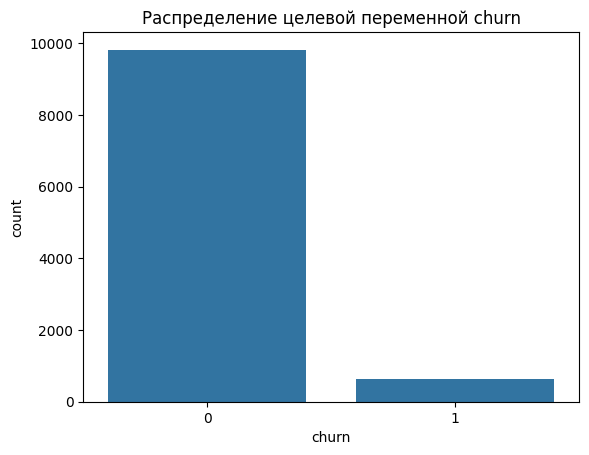

In [124]:
# Распределение целевой переменной churn
sns.countplot(x="churn", data=df)
plt.title("Распределение целевой переменной churn")
plt.show()

**2. Опишите целевую переменную. Обратите внимание на возможные особенности её распределения. Проверьте, наблюдается ли дисбаланс классов в целевой переменной.**
* Наблюдается сильный дисбаланс по столбцу целевой переменной 'churn' 9821 - (0) пользователь продолжает пользоваться сервисом, против 629 (всего 6%) - (1) пользователь перестал пользоваться сервисом.
* Пропусков нет

**3. Опишите признаки. Определите, все ли из них важны. Объясните, какие из них можно удалить (если такие есть). Аргументируйте своё решение.**
* Признаки представлены двумя типами: числовыми (в том числе бинарными), текст.
* Некоторые столбцы содержат пропуски и отрицательные значения (например, отрицательный средний чек).
* Пропуски и отрицательные значения будут заменены на медианные значения.
* Предлагается исключить из анализа:
    * user_id (идентификатор пользователя) - не имеет ценности
    * order_frequency_week (среднее число заказов в неделю) - вместо него достаточно 'order_frequency_month' 
    * avg_order_value (средний чек, в рублях) - вместо него достаточно 'median_order_value' из-за большого разброса
    * total_spent_last_week (сумма заказов за последнюю неделю) - вместо него достаточно 'total_spent_last_month'
    * last_drink_size (размер последнего заказа (стаканчика), совершённого на момент сбора данных) - сомнительный фактор влияния на уход клиента, с учетом дисбаланса ухода, иначе картина была бы более пугающая.
    * phone_type (тип устройства, с которого пользователь чаще всего совершал покупки) - вместо него достаточно 'app_crashes_last_month'.

**4. Обработайте пропущенные значения. Объясните, как они влияют на данные. Выберите стратегию заполнения пропусков.**
* Пропущенных значений в данных примерно от1 до 10% по столбцам.
* Для того, чтобы не исключать 10% данных из анализа предлагается для числовых столбцов использовать медианные значения, чтобы не исключать nan, для бинарных и категоральных использовать самый частый вариант.
* Непосредствено обработка будет выполнена в этапе 3 при проработке pipeline

**5. Проанализируйте категориальные признаки.**

**Выясните, есть ли в данных признаки, которые можно кодировать. Объясните, почему именно их нужно кодировать.**
* Признаки указывают на сам продукт (зерна), способ обжарки и т.д. возможно влияние на решение уйти окарывает как раз качество продукта.
* Признак - Метод кодирования:
    * last_coffee_type - One-Hot (менее 10)
    * preferred_roast - One-Hot (менее 10)
    * milk_preference - One-Hot (менее 10)
    * coffee_bean_origin - One-Hot (менее 10)
    * subscription_status - One-Hot (менее 10)
    * seasons - One-Hot (менее 10)
    * geo_location - TargetEncoder (более 10)

**Проанализируйте признаки на предмет того, можно ли использовать некоторые из них для генерации новых признаков. Укажите возможные стратегии.**
* Исходные данные имеют подробную структуру. 
* Возможно имеет смысл установить связь между рейтингом и тратами за месяц.


**Определите, есть ли в данных признаки, которые можно удалить.**
* Категоральные признаки для удаления (причины указаны выше):
    * user_id
    * last_drink_size
    * phone_type

**6. Проанализируйте выбросы. Определите, как они влияют на данные. Выберите способ, которым их можно обработать.**

* Большая часть данных имеет правый хвост
* Выбросов достаточно много (посчитано по межквартильному размаху), но в то же время они скорее отражают уникальных клиентов, а не ошибки, т.е. просто удалить их нельзя. При построении модели для снижения влияния выбросов применить логарифмирование.

In [125]:
# Считаем выбросы
numeric_cols = [
    'days_since_last_order',
    'order_frequency_month',
    'median_order_value',
    'total_spent_last_month',
    'discount_usage_rate',
    'review_rating_last_10',
    'app_crashes_last_month',
    'days_since_last_promo',
    'app_opens_per_week']
out_of_iqr = {}

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    upper_border = q3 + 1.5 * iqr
    count_upper = (df[col] > upper_border).sum()
    out_of_iqr[col] = count_upper

out_of_iqr = pd.DataFrame(list(out_of_iqr.items()),
                                columns=['column', 'out_of_iqr'])
print("*****Выбросы*****")
print(out_of_iqr)

*****Выбросы*****
                   column  out_of_iqr
0   days_since_last_order         561
1   order_frequency_month         302
2      median_order_value         225
3  total_spent_last_month         594
4     discount_usage_rate          70
5   review_rating_last_10          44
6  app_crashes_last_month           7
7   days_since_last_promo         526
8      app_opens_per_week         355


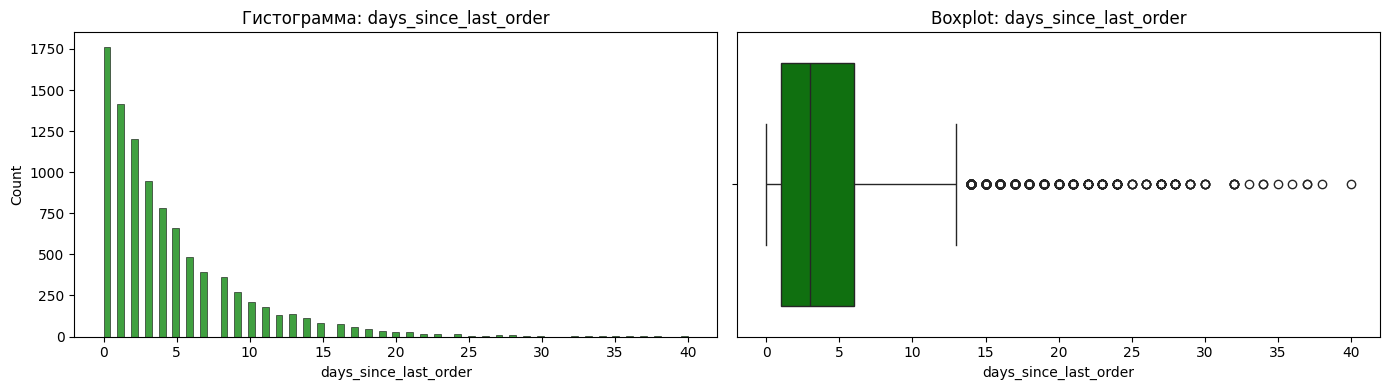

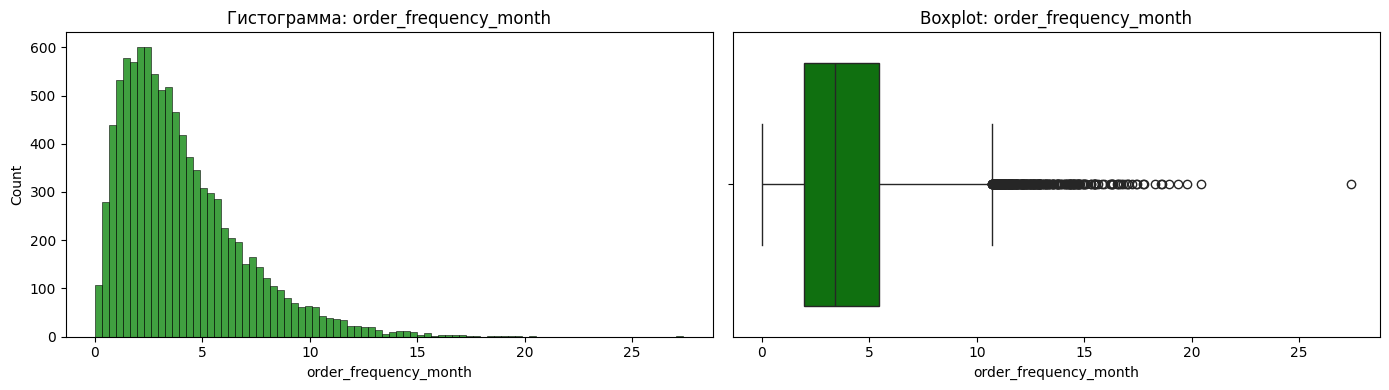

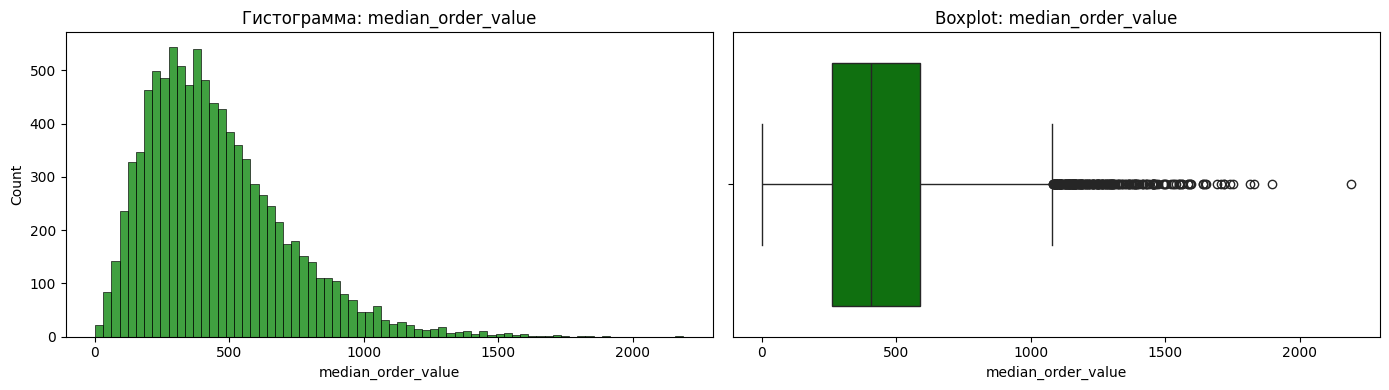

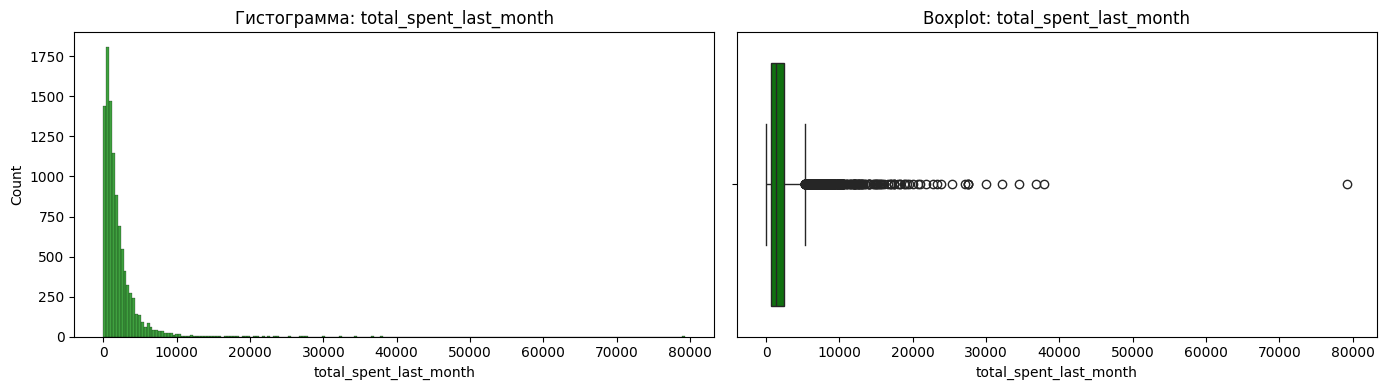

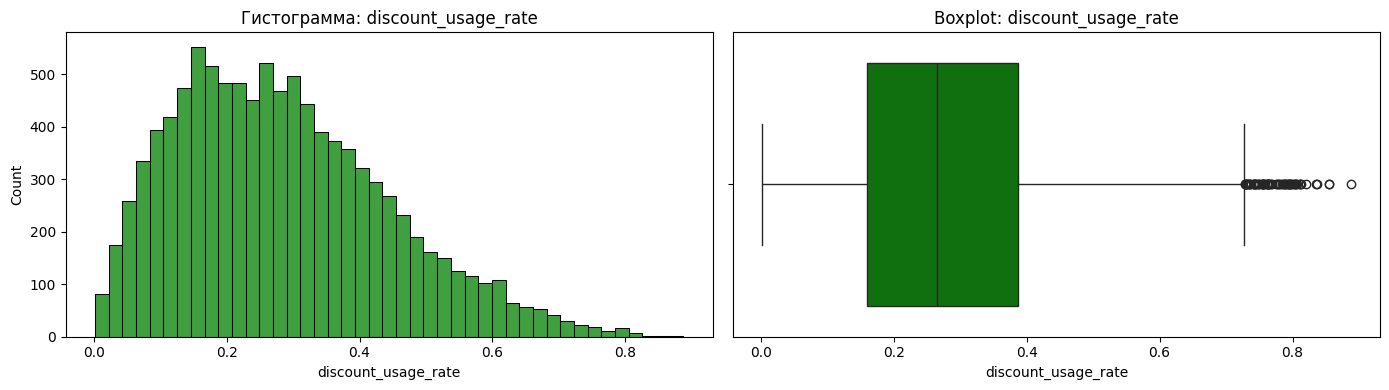

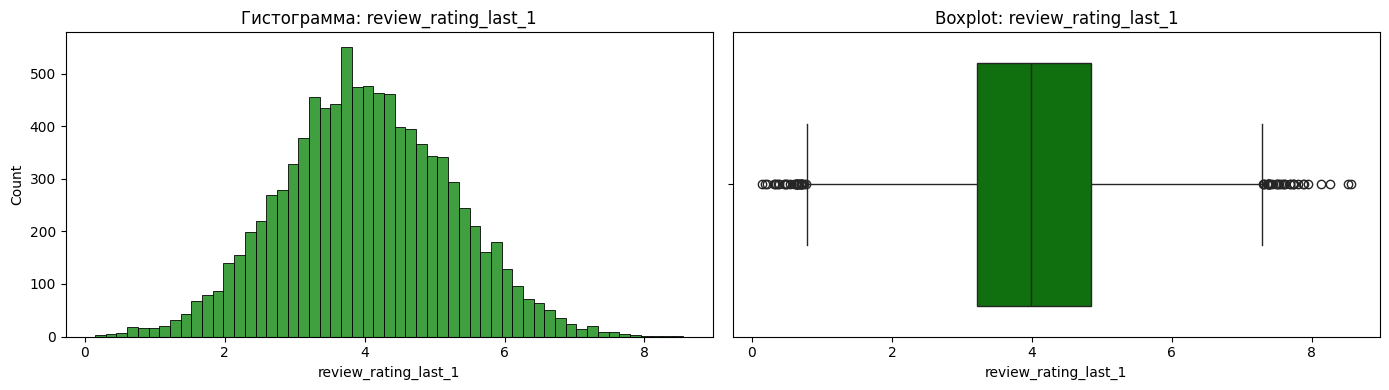

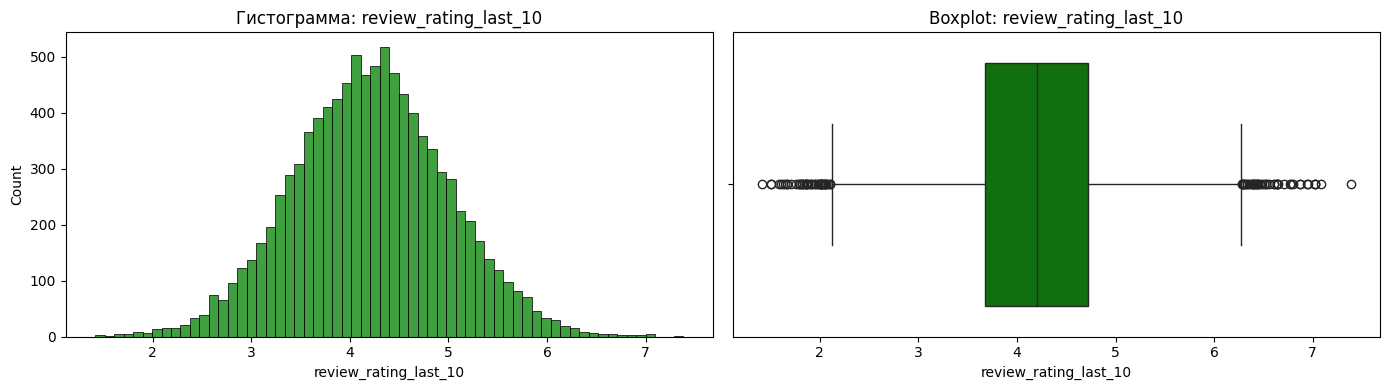

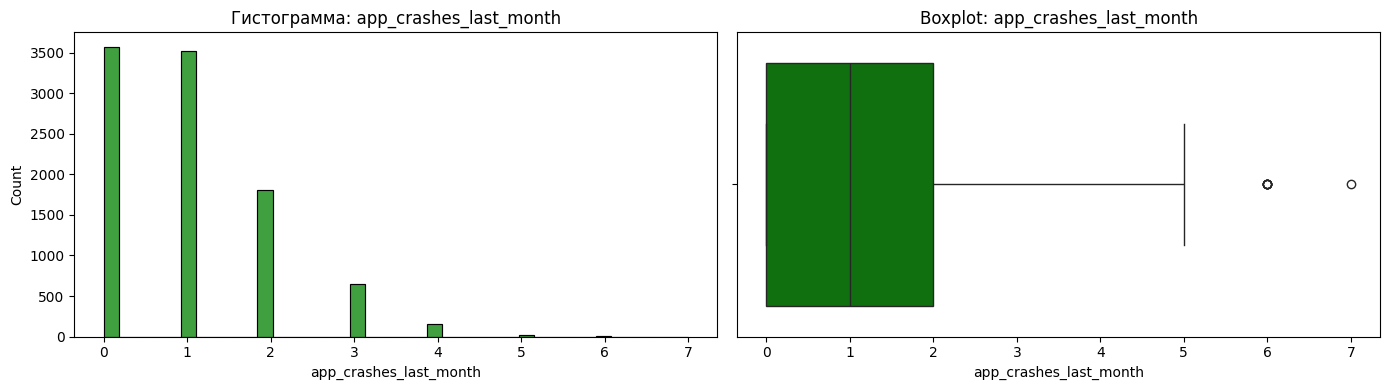

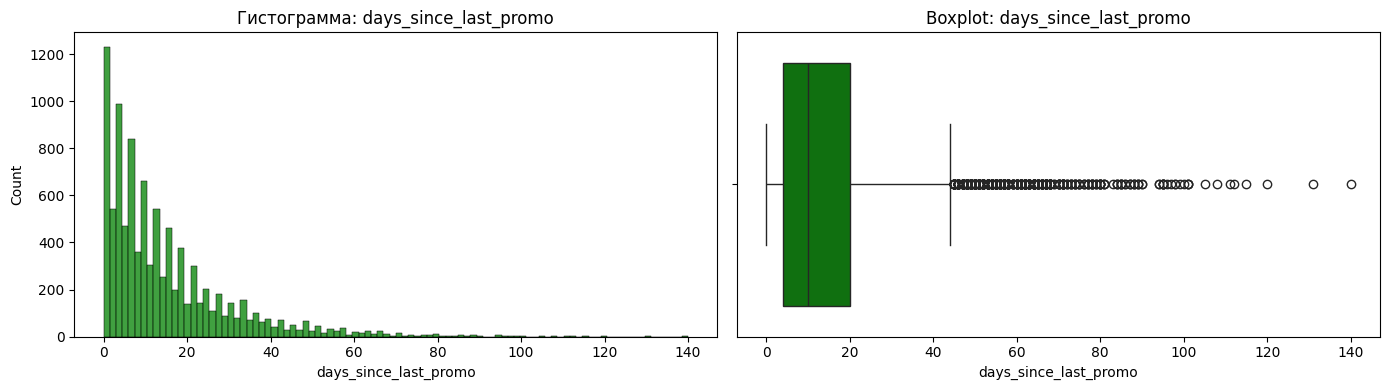

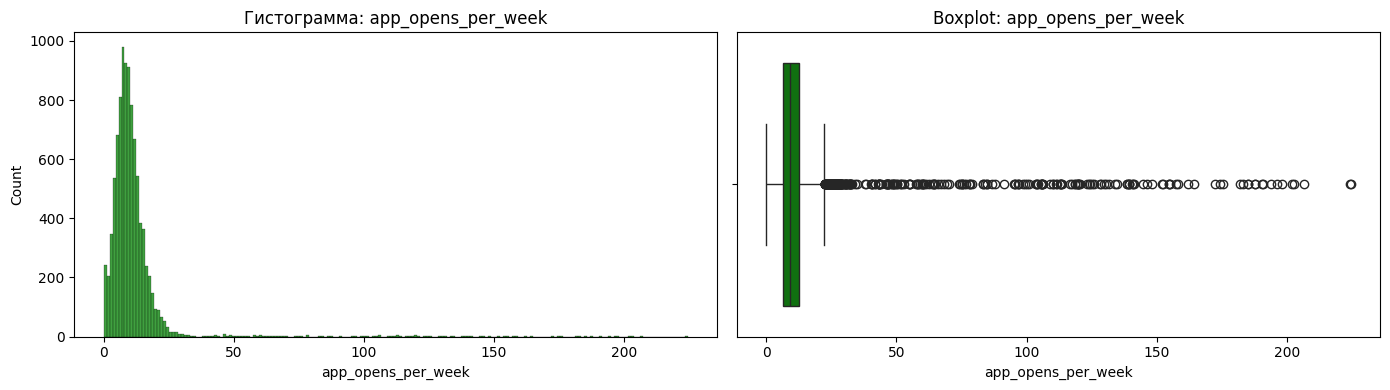

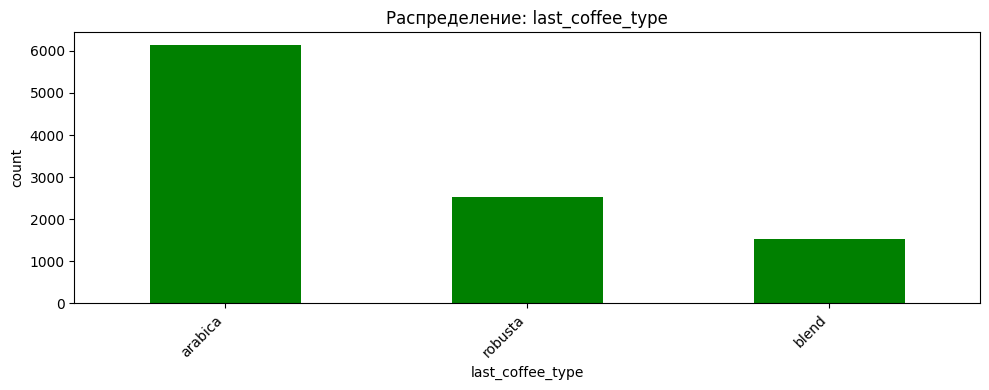

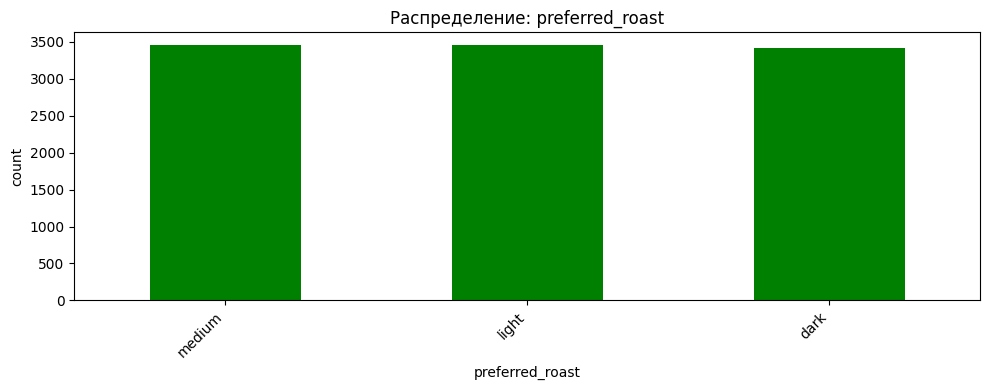

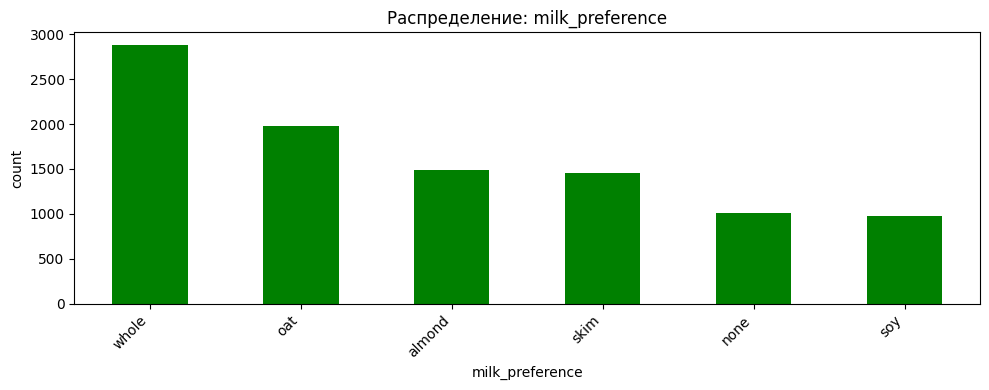

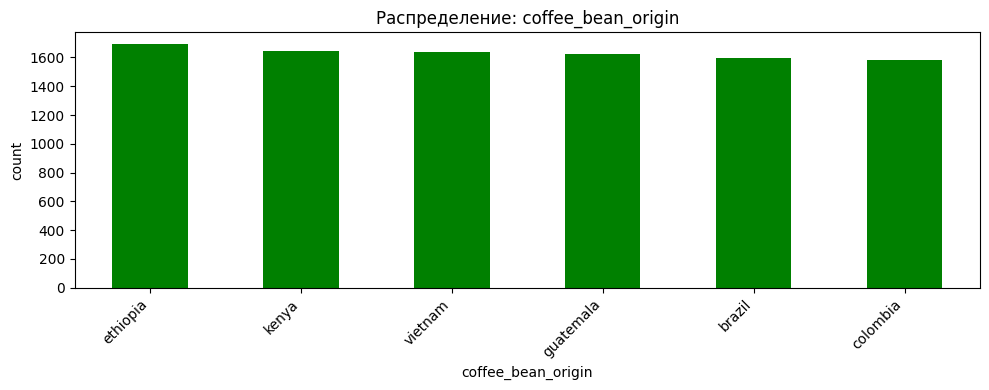

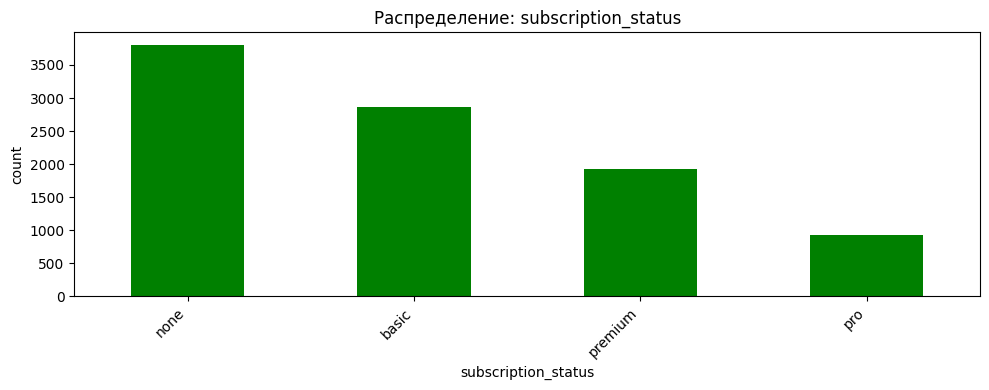

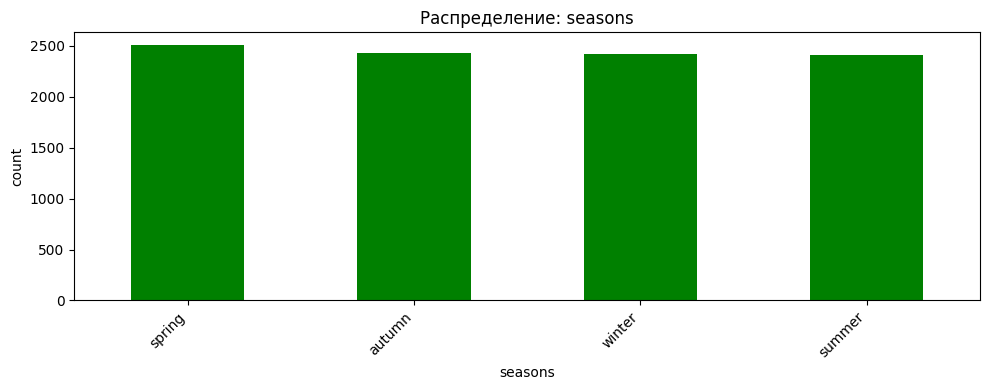

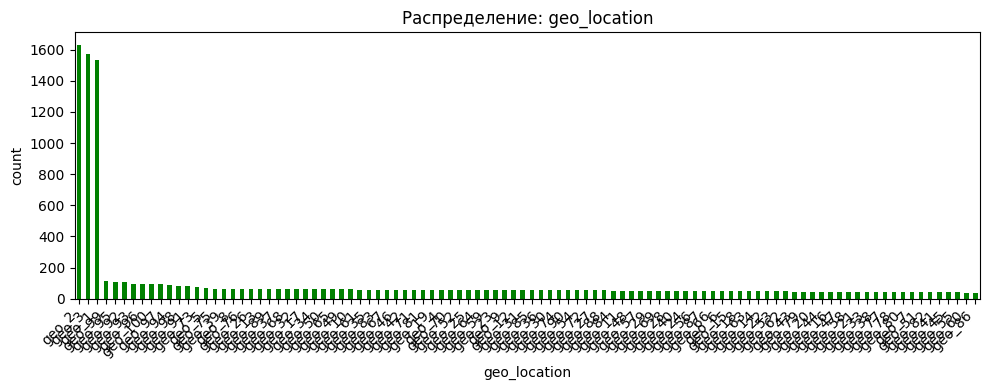

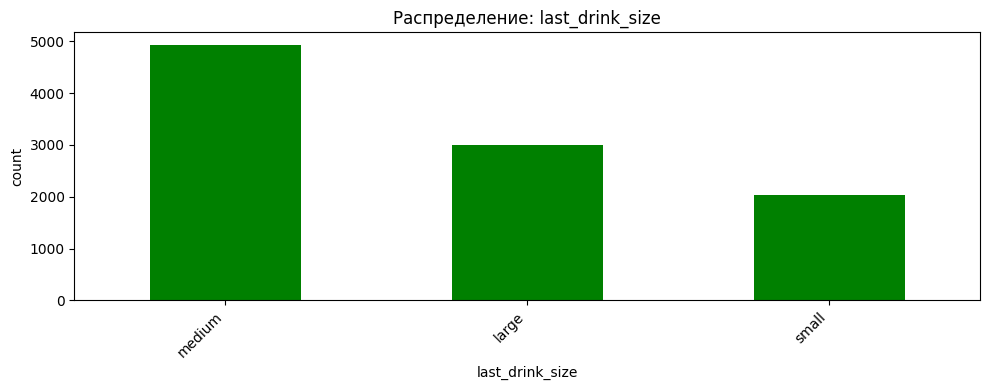

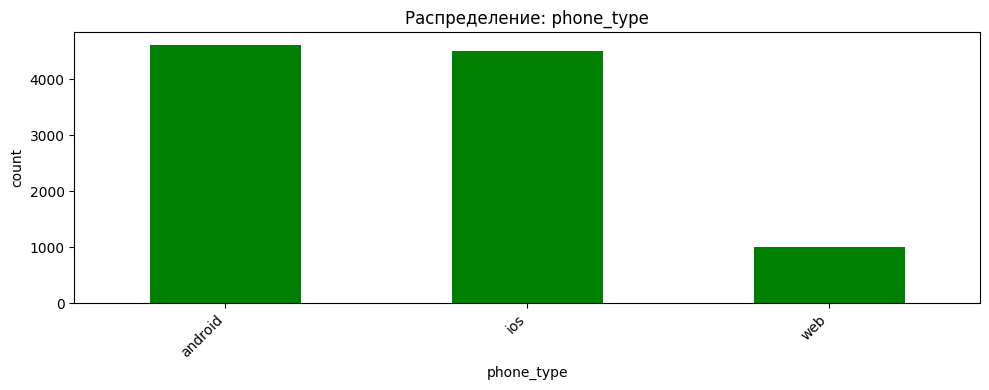

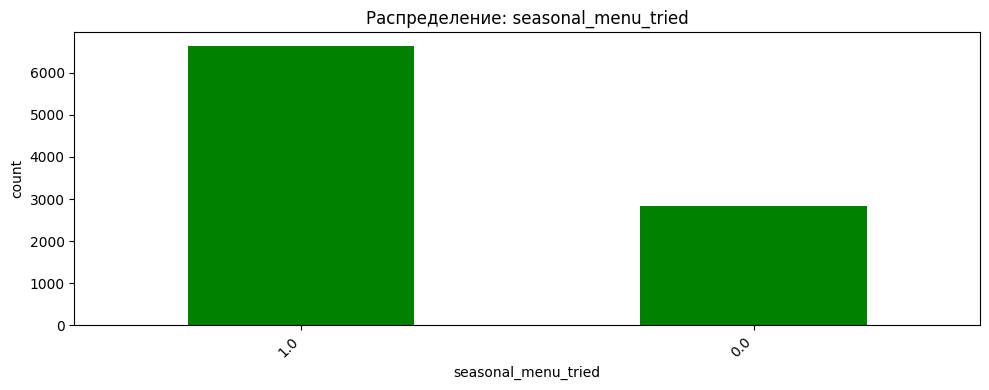

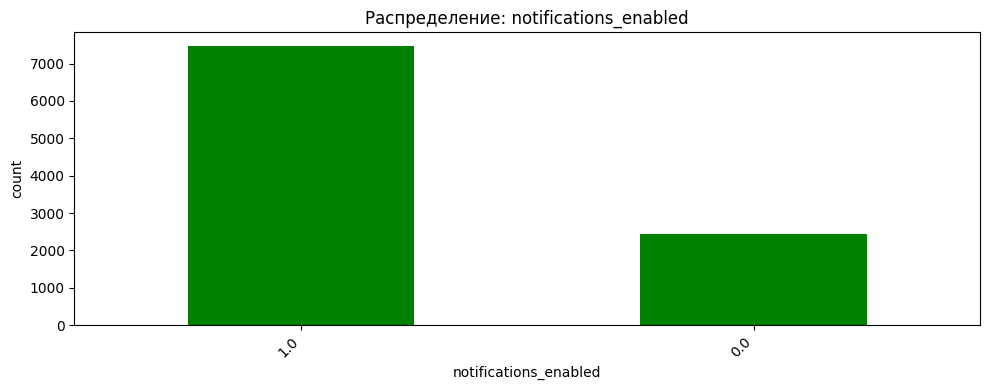

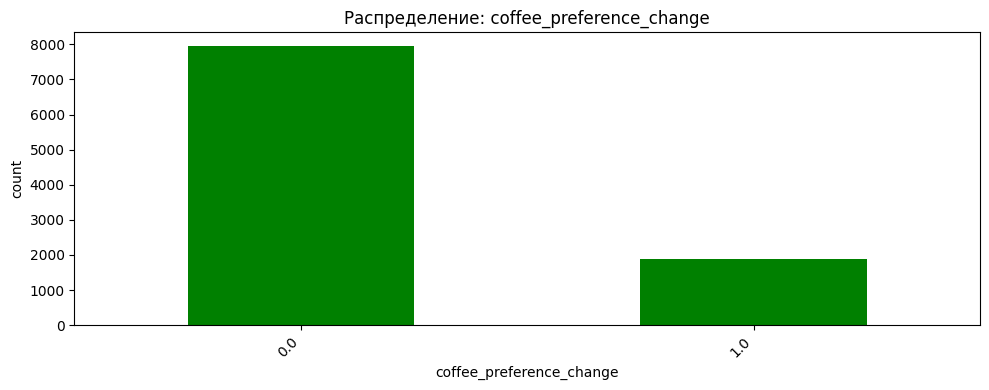

In [126]:
# Типы столбцов
numeric_cols = [
    'days_since_last_order',
    'order_frequency_month',
    'median_order_value',
    'total_spent_last_month',
    'discount_usage_rate',
    'review_rating_last_1',
    'review_rating_last_10',
    'app_crashes_last_month',
    'days_since_last_promo',
    'app_opens_per_week']

categorical_cols = [
    'last_coffee_type',
    'preferred_roast',
    'milk_preference',
    'coffee_bean_origin',
    'subscription_status',
    'seasons',
    'geo_location',
    'last_drink_size',
    'phone_type']

binary_cols = [
    'seasonal_menu_tried',
    'notifications_enabled',
    'coffee_preference_change']

# Гистограммы для числовых
for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    sns.histplot(df[col].dropna(), ax=axes[0], color='green')
    axes[0].set_title(f'Гистограмма: {col}')

    sns.boxplot(x=df[col].dropna(), ax=axes[1], color='green')
    axes[1].set_title(f'Boxplot: {col}')
    plt.tight_layout()
    plt.show()
    
# Гистограммы для категоральных    
for col in categorical_cols:
    plt.figure(figsize=(10, 4))
    df[col].value_counts().plot(kind='bar', color='green')
    plt.title(f'Распределение: {col}')
    plt.ylabel('count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    
# Гистограммы для бинарных    
for col in binary_cols:
    plt.figure(figsize=(10, 4))
    df[col].value_counts().plot(kind='bar', color='green')
    plt.title(f'Распределение: {col}')
    plt.ylabel('count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

**7. Посчитайте корреляции между признаками. Постройте необходимые визуализации. Определите, есть ли признаки, которые можно убрать, на основании их корреляции с другими.**

* Сильная корреляция ожидаемо проявляется между схожими по сути данными, например частота заказов по неделям и месяцам. Ранее уже было предложено не учитывать некоторые из них.
* Некоторые признаки total_spend_last_month и order_frequency_moth показывают ожидаемую заметную корреляцию
* Интересным фактом является то, что churn демонстрирует умеренную корреляцию с частотой поломки приложения.

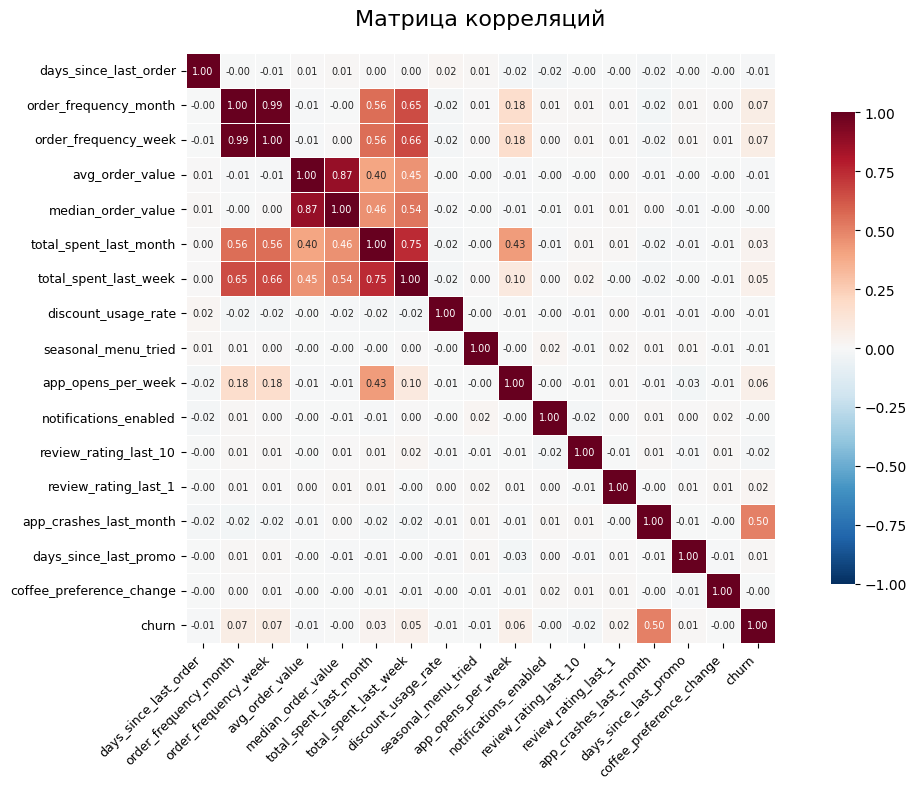

In [127]:
# Оставляем только числовые колонки
df_numeric = df.select_dtypes(include='number')

# Матрица корреляций Пирсона для числовых признаков
corr_matrix = df_numeric.corr(method='pearson')

# Визуализация тепловой карты
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', 
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            annot_kws={'size': 7})
plt.title('Матрица корреляций', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

## Этап 3. Предобработка данных

1. Разделите данные в пропорции 80 к 20. 20% данных отложите для теста. Остальные используйте для обучения и кросс-валидации модели.

2. Предобработайте данные. Используйте информацию о пропусках и категориальных признаках только из обучающей выборки.

   - Создайте пайплайн, который обработает пропуски и выбросы.

   - Создайте пайплайн, который обработает категориальные признаки.

   - Создайте пайплайн, который обработает числовые признаки: проведёт масштабирование и нормализацию.



In [128]:
#  Разделение данных в пропорции 80/20
# Удаляем избыточные признаки
X = df.drop(columns=['user_id', 'order_frequency_week', 'avg_order_value', 'total_spent_last_week', 'last_drink_size', 'phone_type', 'churn']).copy()
y = df['churn'].copy()
X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y)

In [129]:
# Категориальные колонки
# Числовые
numeric_cols = [
    'days_since_last_order',
    'order_frequency_month',
    'median_order_value',
    'total_spent_last_month',
    'discount_usage_rate',
    'review_rating_last_10',
    'app_crashes_last_month',
    'days_since_last_promo',
    'app_opens_per_week',
    'review_rating_last_1']

# Категориальные
# для one-hot
cat_one_hot = [
    'last_coffee_type',
    'preferred_roast',
    'milk_preference',
    'coffee_bean_origin',
    'subscription_status',
    'seasons']

# для target
cat_target = ['geo_location']

# Бинарные
binary_cols = [
    'seasonal_menu_tried',
    'notifications_enabled',
    'coffee_preference_change']

In [130]:
# Пайплайн для one-hot
pipeline_one_hot = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False))])

# Пайплайн для TargetEncoder
pipeline_target = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', TargetEncoder(smoothing=20))])

In [131]:
# Пайплайн для числовых
pipeline_num = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(np.log1p)),
    ('scaler', RobustScaler())])

In [132]:
# Пайплайн для бинарных
pipeline_binary = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))])

In [133]:
# Сборка препроцессора
preprocessor = ColumnTransformer([
    ('num', pipeline_num, numeric_cols),
    ('cat_one_hot', pipeline_one_hot, cat_one_hot),
    ('cat_target', pipeline_target, cat_target),
    ('cat_binary', pipeline_binary, binary_cols)])

# модель LogisticRegression
clf = Pipeline([
    ('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))])

# dummy модель
dummy = Pipeline([
    ('preprocess', preprocessor),
    ('model', DummyClassifier(strategy='stratified', random_state=RANDOM_STATE))])

## Этап 4. Обучение модели

1. Обучите базовую версию модели.
   - Используйте для этого простые статистические модели.

   - Используйте кросс-валидацию для обучения модели.

2. Посчитайте метрики, поставленные в задаче. Опираясь на них, сделайте вывод о качестве модели.

In [134]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Метрики
scoring = [
    'average_precision',
    'precision',
    'recall',
    'roc_auc']

scores_logreg = cross_validate(clf, X_train_temp, y_train_temp, cv=cv, scoring=scoring)
scores_dummy = cross_validate(dummy, X_train_temp, y_train_temp, cv=cv, scoring=scoring)

print("LogReg метрики:")
for score in scoring:
    s = scores_logreg[f'test_{score}']
    print(f"  {score}: {s.mean():.4f}")

print("Dummy метрики:")
for score in scoring:
    s = scores_dummy[f'test_{score}']
    print(f"  {score}: {s.mean():.4f}")

LogReg метрики:
  average_precision: 0.5777
  precision: 0.2635
  recall: 0.8766
  roc_auc: 0.9267
Dummy метрики:
  average_precision: 0.0603
  precision: 0.0607
  recall: 0.0636
  roc_auc: 0.5003


In [135]:
# Смотрим на тесте
clf.fit(X_train_temp, y_train_temp)
y_pred_proba = clf.predict_proba(X_test)[:, 1]

pr_auc_test = average_precision_score(y_test, y_pred_proba)
print("PR-AUC на тестовой выборке:", pr_auc_test)

PR-AUC на тестовой выборке: 0.5778396673531948


In [136]:
model = clf.named_steps['model']
coefs = model.coef_[0]
coefs

array([-1.41110362e-02,  9.15637961e-01,  4.11294714e-01, -7.21979418e-01,
       -4.72443641e-03, -1.18869841e-01,  5.18087724e+00,  2.11283793e-01,
        7.25291166e-01,  1.11795872e-01, -1.70905561e-02,  2.83082954e-01,
       -1.30612241e-01, -3.96546271e-02, -5.45579064e-01, -2.23305402e-01,
       -5.47665899e-01, -7.31844759e-01, -4.33069444e-01, -3.08098448e-01,
        3.62442737e-02, -3.13933856e-01, -2.97362974e-01, -1.01508877e-01,
       -1.22426711e-02,  2.19013117e-01,  9.45499134e-01,  2.44750914e-01,
       -1.50723569e-01, -2.69871785e-03,  8.06202105e+00, -4.42103128e-01,
       -2.25133520e-01, -3.89928368e-02])

**Промежуточный итог**
* Модель logreg показывает результат в 10 (pr_auc: 0.58 против 0.062) раз лучше по сравнению с dummy моделью
* recall высокий (0.8766) - модель хорошо находит клиентов, которые могут уйти.
* При этом precision (0.2641) показывает, что среди отмеченных, только 26% реально собираются уйти.

## Этап 5. Создание новых признаков

1. Добавьте новые признаки, которые могут улучшить качество модели. Опирайтесь на наработки, полученные в ходе исследовательского анализа данных, и на логику решаемой задачи.

   - Извлечение квадратного корня поможет сгладить большие значения.

   - Возведение в квадрат усилит влияние больших значений.

2. Обновите пайплайн для работы с новыми признаками, проведите повторную кросс-валидацию, сравните результаты моделей с новыми признаками и без них.

3. Интерпретируйте коэффициенты модели, а затем на их основании выявите значимые признаки и удалите лишние для модели.

In [137]:

# Еще раз объявляем X и y
X = df.drop(columns=['user_id', 'order_frequency_week', 'avg_order_value',
                     'total_spent_last_week', 'last_drink_size', 'phone_type',
                     'churn']).copy()
y = df['churn'].copy()

# Базовые столбцы
base_numeric_cols = ['days_since_last_order', 'order_frequency_month',
                     'median_order_value', 'total_spent_last_month',
                     'discount_usage_rate', 'review_rating_last_10',
                     'app_crashes_last_month', 'days_since_last_promo',
                     'app_opens_per_week', 'review_rating_last_1']

# Обработанные через sqrt
sqrt_cols_src = ['total_spent_last_month', 'median_order_value',
                 'app_opens_per_week', 'days_since_last_promo']
for col in sqrt_cols_src:
    X[f'{col}_sqrt'] = np.sqrt(X[col].clip(lower=0))

# Обработанные через возведение в квадрат
sqr_cols_src = ['days_since_last_order', 'app_crashes_last_month',
                'review_rating_last_10', 'discount_usage_rate']
for col in sqr_cols_src:
    X[f'{col}_sqr'] = X[col].clip(lower=0) ** 2

# Признаки приведенные
X['recency_freq_ratio'] = X['days_since_last_order'] / (X['order_frequency_month'] + 1)
X['promo_recency_x_discount'] = X['days_since_last_promo'] * X['discount_usage_rate']
X['opens_per_crash'] = X['app_opens_per_week'] / (X['app_crashes_last_month'] + 1)
X['rating_delta'] = X['review_rating_last_1'] - X['review_rating_last_10']
X['rating_x_spend'] = X['review_rating_last_10'] * X['total_spent_last_month']

In [138]:
# Числовые колонки для логарифмирования (исходные + дополнительные)
numeric_cols_log = base_numeric_cols + [
    'total_spent_last_month_sqrt', 'median_order_value_sqrt',
    'app_opens_per_week_sqrt', 'days_since_last_promo_sqrt',
    'promo_recency_x_discount', 'opens_per_crash', 'rating_x_spend',
    'recency_freq_ratio']

# Числовые без логарифма
numeric_cols_no_log = [
    'days_since_last_order_sqr', 'app_crashes_last_month_sqr',
    'review_rating_last_10_sqr', 'discount_usage_rate_sqr', 'rating_delta']

# Категориальные
# для one-hot
cat_one_hot = ['last_coffee_type', 'preferred_roast', 'milk_preference',
               'coffee_bean_origin', 'subscription_status', 'seasons']
# для target
cat_target = ['geo_location']
# Бинарные
binary_cols = ['seasonal_menu_tried', 'notifications_enabled', 'coffee_preference_change']

In [139]:
# Пайплайн для one-hot
pipeline_one_hot = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False))])
# Пайплайн для TargetEncoder
pipeline_target = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', TargetEncoder(smoothing=20))])
# Пайплайн для числовых
pipeline_num = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(np.log1p)),
    ('scaler', RobustScaler())])
# Пайплайн для числовых без логарифмирования
pipeline_num_no_log = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())])
# Пайплайн для бинарных
pipeline_binary = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))])

In [140]:
# Сборка препроцессора
preprocessor = ColumnTransformer([
    ('num', pipeline_num, numeric_cols_log),
    ('num_no_log', pipeline_num_no_log, numeric_cols_no_log),
    ('cat_one_hot', pipeline_one_hot, cat_one_hot),
    ('cat_target', pipeline_target, cat_target),
    ('cat_binary', pipeline_binary, binary_cols)])
# модель LogisticRegression обновленная
clf_new = Pipeline([
    ('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=2000, class_weight='balanced',
                                  random_state=RANDOM_STATE))])

In [141]:
# Разделение и обучение
X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = [
    'average_precision',
    'precision',
    'recall',
    'roc_auc']

scores_logreg_new = cross_validate(clf_new, X_train_temp, y_train_temp,
                                    cv=cv, scoring=scoring)

print("LogReg метрики new:")
for score in scoring:
    s = scores_logreg_new[f'test_{score}']
    print(f"  {score}: {s.mean():.4f}")
    
print("LogReg метрики базовая:")
for score in scoring:
    s = scores_logreg[f'test_{score}']
    print(f"  {score}: {s.mean():.4f}")

print("Dummy метрики:")
for score in scoring:
    s = scores_dummy[f'test_{score}']
    print(f"  {score}: {s.mean():.4f}")

LogReg метрики new:
  average_precision: 0.6877
  precision: 0.3326
  recall: 0.8388
  roc_auc: 0.9345
LogReg метрики базовая:
  average_precision: 0.5777
  precision: 0.2635
  recall: 0.8766
  roc_auc: 0.9267
Dummy метрики:
  average_precision: 0.0603
  precision: 0.0607
  recall: 0.0636
  roc_auc: 0.5003


In [142]:
# Обучаем обновленную модель
clf_new.fit(X_train_temp, y_train_temp)
model = clf_new.named_steps['model']
coefs = model.coef_[0]

# Имена признаков после препроцессора добавляем в том же порядке, что и в препроцессоре
feature_names = []
feature_names.extend(numeric_cols_log)
feature_names.extend(numeric_cols_no_log)
ohe = clf_new.named_steps['preprocess'].named_transformers_['cat_one_hot'].named_steps['encoder']
feature_names.extend(list(ohe.get_feature_names_out(cat_one_hot)))
feature_names.append('geo_location')
feature_names.extend(binary_cols)

# Формируем датафрейм признаков
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coef': coefs,
    'abs_coef': np.abs(coefs)
}).sort_values('abs_coef', ascending=False)

print("*****Коэффициенты (топ-20)*****")
print(coef_df.head(20).to_string(index=False))
print("\n*****Наименее значимые*****")
print(coef_df.tail(10).to_string(index=False))

*****Коэффициенты (топ-20)*****
                    feature      coef  abs_coef
               geo_location  7.284519  7.284519
 app_crashes_last_month_sqr  2.046429  2.046429
      order_frequency_month  1.187350  1.187350
         app_opens_per_week  1.169777  1.169777
    subscription_status_pro  1.017692  1.017692
        milk_preference_soy -0.801407  0.801407
       milk_preference_skim -0.714539  0.714539
total_spent_last_month_sqrt -0.659200  0.659200
        seasonal_menu_tried -0.607267  0.607267
       milk_preference_none -0.590743  0.590743
      milk_preference_whole -0.566181  0.566181
     app_crashes_last_month  0.482356  0.482356
   last_coffee_type_robusta  0.404582  0.404582
 days_since_last_promo_sqrt  0.386459  0.386459
subscription_status_premium  0.335041  0.335041
       review_rating_last_1  0.330033  0.330033
    median_order_value_sqrt  0.312726  0.312726
        discount_usage_rate -0.300553  0.300553
               rating_delta -0.294177  0.294177
coffee_b

In [143]:
# Удаляем малозначимые признаки на основе коэффициентов
cols_to_drop = [
    'review_rating_last_10_sqr',
    'days_since_last_order_sqr',
    'rating_x_spend',
    'days_since_last_promo']

X_filtered = X.drop(columns=cols_to_drop).copy()

for col in ['rating_x_spend', 'days_since_last_promo']:
    numeric_cols_log.remove(col)

for col in ['review_rating_last_10_sqr', 'days_since_last_order_sqr']:
    numeric_cols_no_log.remove(col)

In [144]:
preprocessor_f = ColumnTransformer([
    ('num', pipeline_num, numeric_cols_log),
    ('num_no_log', pipeline_num_no_log, numeric_cols_no_log),
    ('cat_one_hot', pipeline_one_hot, cat_one_hot),
    ('cat_target', pipeline_target, cat_target),
    ('cat_binary', pipeline_binary, binary_cols)])

clf_filtered = Pipeline([
    ('preprocess', preprocessor_f),
    ('model', LogisticRegression(max_iter=2000, class_weight='balanced',
                                  random_state=RANDOM_STATE))])

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_filtered, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
scores_filtered = cross_validate(clf_filtered, X_train_f, y_train_f, cv=cv, scoring=scoring)

print("LogReg метрики new + отсев слабых признаков:")
for score in scoring:
    s = scores_filtered[f'test_{score}']
    print(f"  {score}: {s.mean():.4f}")

LogReg метрики new + отсев слабых признаков:
  average_precision: 0.6899
  precision: 0.3329
  recall: 0.8388
  roc_auc: 0.9352


**Промежуточные итоги**
* Самый сильный признак geo_location (7.41) имеет подозрительно высокое значение. Скорее всего его вес обусловлен не естественными причинами, а проблемами в конкретных точках. В рамках учебной задачи его стоит оставить, но в реальном примере потребовалось бы дополнительное исследование причин или исключение признака.
* app_crashes_last_month_sqr, order_frequency_month, subscription_status_pro, app_opens_per_week также сильно влияют- иными словами, чем чаще и глубже потребитель пользуется сервисом и натыкается на сбои, тем сильнее он недоволен и готов уйти.
* После добавления новых признаков, часть из них действительно привело к улучшению модели.

## Этап 6. Эксперименты с гиперпараметрами

1. Перечислите все гиперпараметры, с которыми планируете экспериментировать.

2. Проведите систематический перебор гиперпараметров для `LogisticRegression`, выполните кросс-валидацию для каждой конфигурации.

3. Составьте таблицу с результатами.

4. Выберите лучшую модель, ориентируясь на заданную метрику качества.

In [145]:
# Сила регуляции
C_values = [0.001, 0.01, 0.1, 1.0, 10.0]

# Доля L1 в elasticnet (0 = чистый L2, 1 = чистый L1)
l1_ratio_values = [0.1, 0.3, 0.5, 0.7, 0.9]

# Перебор по гиперпараметрам с кросс-валидацией
results = []

for C in C_values:
    for l1_ratio in l1_ratio_values:
        # Создаём пайплайн с текущей конфигурацией
        pipe = Pipeline([
            ('preprocess', preprocessor_f),
            ('model', LogisticRegression(
                C=C,
                penalty='elasticnet',
                solver='saga',
                l1_ratio=l1_ratio,
                class_weight='balanced',
                max_iter=2000,
                random_state=RANDOM_STATE))])

        # Кросс-валидация
        cv_scores = cross_validate(pipe, X_train_f, y_train_f, cv=cv, scoring=scoring)

        # Усредняем метрики по фолдам
        row = {
            'C': C,
            'l1_ratio': l1_ratio,
            'average_precision':     cv_scores['test_average_precision'].mean(),
            'average_precision_std': cv_scores['test_average_precision'].std(),
            'precision':             cv_scores['test_precision'].mean(),
            'recall':                cv_scores['test_recall'].mean(),
            'roc_auc':               cv_scores['test_roc_auc'].mean()}

        results.append(row)
        print(f"C={C:<7} & l1_ratio={l1_ratio:<3} >>> PR-AUC={row['average_precision']:.4f}")

# Таблица с результатами
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('average_precision', ascending=False).reset_index(drop=True)

print("\n" + "*" * 80)
print("Таблица результатов")
print("*" * 80)
print(results_df.to_string(index=False))
print("*" * 80)

# Выбор лучшей модели по PR-AUC
best_row = results_df.iloc[0]
print(f"\nЛучшая конфигурация:")
print(f"  C         = {best_row['C']}")
print(f"  l1_ratio = {best_row['l1_ratio']}")
print(f"  PR-AUC    = {best_row['average_precision']:.4f}")
print(f"  Precision = {best_row['precision']:.4f}")
print(f"  Recall    = {best_row['recall']:.4f}")
print(f"  ROC-AUC   = {best_row['roc_auc']:.4f}")


C=0.001   & l1_ratio=0.1 >>> PR-AUC=0.6947
C=0.001   & l1_ratio=0.3 >>> PR-AUC=0.6970
C=0.001   & l1_ratio=0.5 >>> PR-AUC=0.7036
C=0.001   & l1_ratio=0.7 >>> PR-AUC=0.7029
C=0.001   & l1_ratio=0.9 >>> PR-AUC=0.5353
C=0.01    & l1_ratio=0.1 >>> PR-AUC=0.6964
C=0.01    & l1_ratio=0.3 >>> PR-AUC=0.6982
C=0.01    & l1_ratio=0.5 >>> PR-AUC=0.6982
C=0.01    & l1_ratio=0.7 >>> PR-AUC=0.6962
C=0.01    & l1_ratio=0.9 >>> PR-AUC=0.6954
C=0.1     & l1_ratio=0.1 >>> PR-AUC=0.6948
C=0.1     & l1_ratio=0.3 >>> PR-AUC=0.6960
C=0.1     & l1_ratio=0.5 >>> PR-AUC=0.6967
C=0.1     & l1_ratio=0.7 >>> PR-AUC=0.6977
C=0.1     & l1_ratio=0.9 >>> PR-AUC=0.6986
C=1.0     & l1_ratio=0.1 >>> PR-AUC=0.6899
C=1.0     & l1_ratio=0.3 >>> PR-AUC=0.6902
C=1.0     & l1_ratio=0.5 >>> PR-AUC=0.6901
C=1.0     & l1_ratio=0.7 >>> PR-AUC=0.6893
C=1.0     & l1_ratio=0.9 >>> PR-AUC=0.6856
C=10.0    & l1_ratio=0.1 >>> PR-AUC=0.6813
C=10.0    & l1_ratio=0.3 >>> PR-AUC=0.6800
C=10.0    & l1_ratio=0.5 >>> PR-AUC=0.6789
C=10.0    &

**Промежуточные итоги**
* Принятые гиперпараметры:
    * сила регуляризации (С) - 0.1
    * тип регуляризации (penalty) - elasticnet (l1_ratio = 0.9)
    * алгоритм оптимизации (solver) - saga
    * максимум итераций (max_iter) - 2000
* ИТОГО показатели модели:
    * PR-AUC    = 0.6986
    * Precision = 0.3427
    * Recall    = 0.8507
    * ROC-AUC   = 0.9361

**Примечание:** в качестве итоговых приняты не "лучшие" гиперпараметры по PR-AUC, т.к. в ходе анализа было выявлено, что при построении модели такой подход обнуляет практически все признаки, а модель выглядит слишком оптимистично, для сохранения баланса сила регуляризации была снижена, что позволило сохранить признаки и сделать модель более честной.

## Этап 7. Подготовка финальной модели

Объедините лучшую конфигурацию гиперпараметров с оптимальным набором признаков. Обучите модель на всех данных для кросс-валидации и проведите финальную оценку на отложенной тестовой выборке.


In [146]:
# Финальная модель с лучшими гиперпараметрами
final_model = Pipeline([
    ('preprocess', preprocessor_f),
    ('model', LogisticRegression(
        C=0.1,
        penalty='elasticnet',
        l1_ratio = 0.9,
        solver='saga',
        class_weight='balanced',
        max_iter=2000,
        random_state=RANDOM_STATE))])

# Кросс-валидация финальной модели на обучающих данных
print("Кросс-валидация финальной модели (на обучающих данных):")
scores_final = cross_validate(final_model, X_train_f, y_train_f, cv=cv, scoring=scoring)
for score in scoring:
    s = scores_final[f'test_{score}']
    print(f"  {score}: {s.mean():.4f}")

Кросс-валидация финальной модели (на обучающих данных):
  average_precision: 0.6986
  precision: 0.3427
  recall: 0.8507
  roc_auc: 0.9361


In [147]:
# Обучение на всех данных для кросс-валидации
final_model.fit(X_train_f, y_train_f)

# Финальная оценка на отложенной тестовой выборке
y_pred_proba = final_model.predict_proba(X_test_f)[:, 1]
y_pred = final_model.predict(X_test_f)

pr_auc_test = average_precision_score(y_test_f, y_pred_proba)
precision_test = precision_score(y_test_f, y_pred, zero_division=0)
recall_test = recall_score(y_test_f, y_pred, zero_division=0)

print("Финальная оценка на отложенной тестовой выборке:")
print(f"  average_precision:    {pr_auc_test:.4f}")
print(f"  Precision: {precision_test:.4f}")
print(f"  Recall:    {recall_test:.4f}")

Финальная оценка на отложенной тестовой выборке:
  average_precision:    0.7356
  Precision: 0.3583
  Recall:    0.8730


In [148]:
# Обучаем обновленную модель

model = final_model.named_steps['model']
coefs = model.coef_[0]

# Имена признаков после препроцессора добавляем в том же порядке, что и в препроцессоре
feature_names = []
feature_names.extend(numeric_cols_log)
feature_names.extend(numeric_cols_no_log)
ohe = final_model.named_steps['preprocess'].named_transformers_['cat_one_hot'].named_steps['encoder']
feature_names.extend(list(ohe.get_feature_names_out(cat_one_hot)))
feature_names.append('geo_location')
feature_names.extend(binary_cols)

# Формируем датафрейм признаков
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coef': coefs,
    'abs_coef': np.abs(coefs)
}).sort_values('abs_coef', ascending=False)

print("*****Коэффициенты (топ-20)*****")
print(coef_df.head(20).to_string(index=False))
print("\n*****Наименее значимые*****")
print(coef_df.tail(10).to_string(index=False))

*****Коэффициенты (топ-20)*****
                    feature      coef  abs_coef
 app_crashes_last_month_sqr  2.020972  2.020972
               geo_location  1.193901  1.193901
      order_frequency_month  0.908313  0.908313
    subscription_status_pro  0.874444  0.874444
         app_opens_per_week  0.846022  0.846022
total_spent_last_month_sqrt -0.542038  0.542038
        seasonal_menu_tried -0.500752  0.500752
        milk_preference_soy -0.359488  0.359488
     app_crashes_last_month  0.353511  0.353511
       milk_preference_skim -0.348244  0.348244
   last_coffee_type_robusta  0.341240  0.341240
      milk_preference_whole -0.266871  0.266871
coffee_bean_origin_ethiopia  0.262381  0.262381
 days_since_last_promo_sqrt  0.245886  0.245886
    median_order_value_sqrt  0.219248  0.219248
subscription_status_premium  0.211888  0.211888
       milk_preference_none -0.203388  0.203388
             seasons_spring  0.150882  0.150882
      preferred_roast_light -0.145582  0.145582
      no

## Этап 8. Отчёт о проделанной работе

Проанализируйте итоговые метрики модели и факторы, которые на них повлияли. Составьте описание, выделив наиболее важные факторы.

**Анализ данных**
* Исследованные данные содержали 10450 строк и 27 столбцов.
* Небольшая часть данных содержала ошибки (отрицательные значения) или пропуски (до 10%). Они были замененны или на медианные значения или на наиболее частые (для категоральных). Это позволило сохранить оригинальное количство строк.
* Сохранение строк имело значение т.к. целевая переменная churn имела сильный дисбаланс (данные содержали всего примерно 6% значений, указывающих на уход клиента)
* Данные имели сильный правый хвост. Было принято решение сохранить все значения, т.к. они отражают уникальных клиентов.
* Матрица корреляции показала ожидаемую связь между схожими признаками (например, order_frequency_month и order_frequency_week). Было принято решение удалить часть из них и еще несколько столбцов, ценность которых показалась незначительной для упрощения модели ('user_id', 'order_frequency_week', 'avg_order_value', 'total_spent_last_week', 'last_drink_size', 'phone_type')
* Интересный факт: churn демонстрирует умеренную корреляцию с частотой поломки приложения. Единственный признак с которым chunk показывает такую сильную корреляцию.


**Построение модели**
* Первичная модель logreg показала результат в 10 раз лучше (pr_auc: 0.58 против 0.062) по сравнению с dummy моделью. precision: 0.2641 и recall: 0.8766
* В ходе построения pipeline числовые признаки были обработаны логарифмированием для снижения влияния выбросов.
* Категоральные обработаны через One-Hot (менее 10 признаков), geo_location через TargetEncoder (более 10 признаков)
* Затем были добавлены дополнительные признаки (отражающие связь между признаками, а также признаки усиления текущих (возведение в квадрат) и ославбения (извлечение корня)) для усилинения модели.
* Самым сильным признаком, влияющим на отток оказался geo_location (7.4), далее app_crashes_last_month_sqr (2.05), order_frequency_month (1.2), subscription_status_pro (1.02), т.е. помимо локации **значение имеет качество работы приложения в привязке к частоте заказов и ожиданиям определенного уровня услуг у пользователя**
* В тоже время признаки, указывающие на ассортимент и доспупные опции, наоборот снижают вероятность оттока.
* После анализа часть признаков с низкими весами исключены для облегчения модели ('review_rating_last_10_sqr', 'days_since_last_order_sqr', 'rating_x_spend', 'days_since_last_promo')
* Было проведено повторное обучение с различными гиперпараметрами. По итогу принята модель LogisticRegression со следующими значениями:
    * C=0.1,
    * penalty='elasticnet',
    * l1_ratio = 0.9,
    * solver='saga',
    * class_weight='balanced',
    * max_iter=2000,
    * random_state=RANDOM_STATE
* **Итоговые метрики (на обучающих данных)**: 
    * pr_auc: 0.6986
    * precision: 0.3427
    * recall: 0.8507
* **Итоговые метрики (на тестовых данных)**: 
    * pr_auc: 0.7356 (+5,3%)
    * precision: 0.3583
    * recall: 0.8730
    
**Наблюдения**
* Функция определения уйдет клиент или нет отражает только саму вероятность, но никак не влияет на первопричины оттока. рекомендуется провести анализ первопричин оттока, а не пытаться сразу принимать меры на удержание недовольного клиента, особенно с учетом того, что  precision: 0.3548 говорит нам о том, что 65% клиентов, отмеченных как уходящие, в реальности скорее всего не уйдут. Особое внимание обратить на дисбаланс geo_location и качество (бесперебойность) работы сервиса. Также еще раз стоит отметить: политика разнообразия ассортимента положительно сказывается на удержании клиентов. Возможно исправление первопричин окажется дешевле и выгоднее в долгосрочной перспективе.

## Этап 9. Сохранение модели для продакшена

Сохраните итоговую модель и пайплайн предобработки. Убедитесь, что всё работает: загрузите артефакты и проверьте их на тестовых данных. В решении укажите ссылку для скачивания сохранённых файлов.

In [149]:
# Сохраняем модель 
joblib.dump(final_model, 'final_model.joblib')

['final_model.joblib']

**Ссылка на Git:** https://github.com/FaradRF/s12_happy_beans_coffee_project.git

**Комментарий для ревьюера:** Привет. честно признаюсь, ИИ использовал, но все таки не бездумно, с чем-то не соглашался, делал по своему, что-то не понимал и лез дальше разбираться, чтобы хотя бы понять почему так, а не как хотел изначально. Тема дается тяжело. Не совсем понятна культура написания таких предсказаний, мне почему-то казалось, что сначала надо провести аналитику и определиться со стратегией, что бизнес считает рисками оттока, все, что за скобками - повод искать первопричины, а не давать скидки, как, например, с geo_location. А здесь как-будто наоборот, мы хотим взять все признаки, засунуть все в модель, убрать, что-то добавить и получить уже результат идентификации ошибки, а не стремимся понять почему она вообще появилась. хотя может это всего лишь учебный проект и зря закапываюсь. 